In [1]:
import pandas as pd
import pyranges as pr
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%reload_ext memory_profiler

### **Functions def**

In [2]:
def load_motifs(motifs_file):
    columns = ["Chromosome", "Start", "End", "Motif_name", "Strand", "Motif_Matched"]
    motifs = pd.read_csv(motifs_file, sep="\t", names=columns)
    motifs["second_idx"] = range(1, len(motifs) + 1)
    motifs["Chromosome"] = motifs["Chromosome"].astype(str)
    return motifs

In [3]:
def load_danio_code(PADRE_file):
    columns = ["Chromosome", "Start", "End", "Regulatory_Element", "Score", "Strand", "thickStart", "thickEnd", "itemRgb"]
    PADRE = pd.read_csv(PADRE_file, sep="\t", names=columns, header=None)
    return PADRE

In [4]:
# Filter to keep only the regulatory element of interest
def filter_PADRE(PADRE_df,regulatory_element_tag='EnhA1'):
    return PADRE_df.loc[PADRE_df['Regulatory_Element'].str.contains(r'{0}'.format(regulatory_element_tag), regex=True)==True]

In [5]:
# Scaffolds decrease confidence, we filter them out
def filter_chr(df,file):
    if file=='PADRE':
        resolved_chr = [f'chr{i}' for i in range(1,25+1)]
        resolved_chr.append('chrM')
    else:
        resolved_chr = [f'{i}' for i in range(1,25+1)]
        resolved_chr.append('M')
    return df[df["Chromosome"].isin(resolved_chr)]

In [6]:
def get_enhancers_length(df):
    df['Length'] = df['End'] - df ['Start'] + 1
    return df

In [7]:
def get_percentage(part, whole):
  return 100 * float(part)/float(whole)

### **Files Loading and parameters**

In [8]:
### Parameters: type of enhancer
enhancer = '5_EnhA1' #'7_EnhWk1' #'6_EnhFlank' 

In [9]:
## Files
PADRE_file = "/path_to_Reference/DANIO-CODE_annotations/longPec_PADREs.bed"

motifs_file = "../DCM_motifs_in_Genome/Danio_rerio/Ensembl/dcm_motifs_zero_based.bed"

In [10]:
## Load DANIO-Code annotation 
enhancers_PADRE_ = filter_PADRE(load_danio_code(PADRE_file),enhancer)
enhancers_PADRE__ = filter_chr(enhancers_PADRE_,'PADRE')
enhancers_PADRE = get_enhancers_length(enhancers_PADRE__)
enhancers_PADRE['enhancer_ID'] = enhancers_PADRE['Chromosome'].astype(str) + ':' + enhancers_PADRE['Start'].astype(str) + '-' + enhancers_PADRE['End'].astype(str) 
enhancers_PADRE.head(3)

/local/scratch/tmp/ipykernel_3993378/2663199010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Length'] = df['End'] - df ['Start'] + 1
/local/scratch/tmp/ipykernel_3993378/2541979814.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancers_PADRE['enhancer_ID'] = enhancers_PADRE['Chromosome'].astype(str) + ':' + enhancers_PADRE['Start'].astype(str) + '-' + enhancers_PADRE['End'].astype(str)


,Chromosome,Start,End,Regulatory_Element,Score,Strand,thickStart,thickEnd,itemRgb,Length,enhancer_ID
17,chr19,20216548,20217107,5_EnhA1,1000,.,20216548,20217107,"227,26,28",560,chr19:20216548-20217107
22,chr5,32591371,32592502,5_EnhA1,1000,.,32591371,32592502,"227,26,28",1132,chr5:32591371-32592502
51,chr19,15837578,15838096,5_EnhA1,1000,.,15837578,15838096,"227,26,28",519,chr19:15837578-15838096


In [11]:
### Load motifs
motifs = filter_chr(load_motifs(motifs_file),'_')
# Match the Chromosome format of Danio Code
motifs['Chromosome'] = 'chr' + motifs['Chromosome'].astype(str)
motifs.head(3)

/local/scratch/tmp/ipykernel_3993378/2728184130.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  motifs = pd.read_csv(motifs_file, sep="\t", names=columns)


,Chromosome,Start,End,Motif_name,Strand,Motif_Matched,second_idx
0,chr1,330,335,1_330_335_rev,-,CCTGG,1
1,chr1,330,335,1_330_335_for,+,CCTGG,2
2,chr1,1012,1017,1_1012_1017_rev,-,CCTGG,3


No strand information is provided in Danio Code. In motifs, each motif is provided on both strand, so it can be seen as duplicates in this case. As we compute proportions, it should not be problematic; otherwise we'll just remove the second strand information i.e. drop duplicates.

**Which motifs are included in the enhancers?**

In [12]:
motifs_ranges = pr.PyRanges(motifs)
enhancers_ranges = pr.PyRanges(enhancers_PADRE)

In [13]:
motifs_in_enhancers = motifs_ranges.join(enhancers_ranges, how='containment',report_overlap=True)
motifs_in_enhancers = motifs_in_enhancers.df[motifs_in_enhancers.df["Overlap"]>=5]
motifs_in_enhancers.head(3)

,Chromosome,Start,End,Motif_name,Strand,Motif_Matched,second_idx,Start_b,End_b,Regulatory_Element,Score,Strand_b,thickStart,thickEnd,itemRgb,Length,enhancer_ID,Overlap
0,chr1,17152,17157,1_17152_17157_for,+,CCAGG,48,16785,17260,5_EnhA1,1000,.,16785,17260,"227,26,28",476,chr1:16785-17260,5
1,chr1,52620,52625,1_52620_52625_for,+,CCAGG,129,52482,52728,5_EnhA1,538,.,52482,52728,"227,26,28",247,chr1:52482-52728,5
2,chr1,310291,310296,1_310291_310296_for,+,CCAGG,567,310024,310755,5_EnhA1,879,.,310024,310755,"227,26,28",732,chr1:310024-310755,5


#### **Proportions and Analysis of motifs**

How many enhancers do contain at least one motif?

In [19]:
enhancer_with_motif = len(motifs_in_enhancers['enhancer_ID'].unique())
total_nb_enhancers = len(enhancers_PADRE['enhancer_ID'].unique())
enhancer_without_motif = total_nb_enhancers - enhancer_with_motif

Text(0.5, 1.0, 'Proportion of active enhancers with at least one DCM motif versus. without. \nAnnotation: DANIO-CODE, longPec stage.')

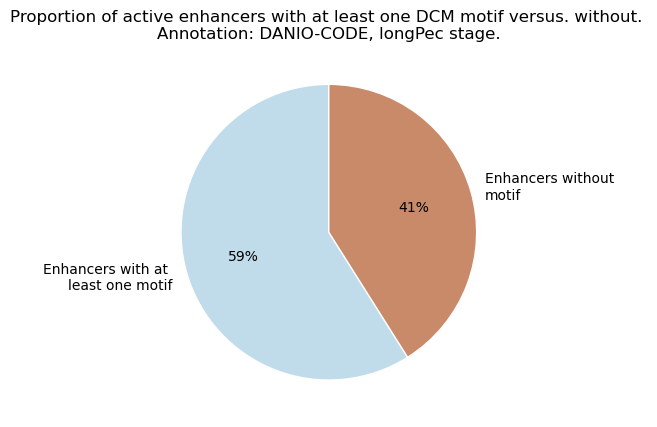

In [23]:
# Percentages
percent_enhancers_with_motif=round(get_percentage(enhancer_with_motif,total_nb_enhancers),2)
percent_enhancers_without_motif=round(get_percentage(enhancer_without_motif,total_nb_enhancers),2)

fig, ax = plt.subplots()
percentage=[percent_enhancers_with_motif,percent_enhancers_without_motif]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)),alpha=0.7)
ax.pie(percentage, labels=["Enhancers with at \nleast one motif", "Enhancers without \nmotif"], autopct='%1.0f%%', colors=colors,startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title("Proportion of active enhancers with at least one DCM motif versus. without. \nAnnotation: DANIO-CODE, longPec stage.")

*How many motifs are found in several enhancers?*

In [38]:
len(motifs_in_enhancers[motifs_in_enhancers['second_idx'].duplicated()])

0

*Distribution of the chromosomes on which the "DCM motifs in enhancers" are found*

In [39]:
# In which chromosomes are found the "DCM motifs in enhancer"?
chr_lengths = pd.read_csv("../Reference/Ensembl/danio_rerio_chr_lengths.txt",sep='\t',names=['Chromosome', 'Length'], header=None)
#Match the format by adding 'chr'
chr_lengths['Chromosome'] = 'chr' + chr_lengths['Chromosome'].astype(str)
tmp=pd.DataFrame(motifs_in_enhancers["Chromosome"].value_counts())
tmp=tmp.rename(columns={'count':'Nb of "DCM motifs in enhancers" for each chr'}).reset_index()
tmp_merged = tmp.merge(chr_lengths)
tmp_merged['count_normalized']=tmp_merged['Nb of "DCM motifs in enhancers" for each chr']/tmp_merged['Length']
tmp_merged.head(3)

,Chromosome,"Nb of ""DCM motifs in enhancers"" for each chr",Length,count_normalized
0,chr5,684,72500376,0.000009
1,chr7,634,74282399,0.000009
2,chr1,562,59578282,0.000009


<Figure size 2500x1500 with 0 Axes>

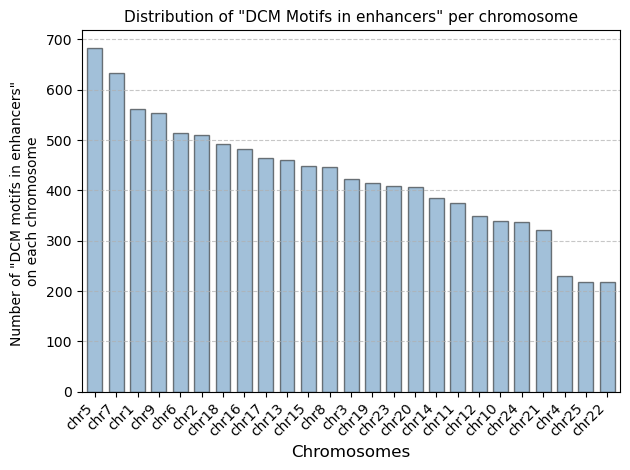

In [40]:
plt.figure(figsize=(25,15))

# Distribution of DCM motifs in Ensembl annotation, not normalized
tmp_merged.plot.bar(x='Chromosome',y='Nb of "DCM motifs in enhancers" for each chr', color='steelblue', edgecolor='black', width=0.7, alpha=0.5, legend=False)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of "DCM motifs in enhancers" \non each chromosome', fontsize=10)
plt.title('Distribution of "DCM Motifs in enhancers" per chromosome', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 4000x2000 with 0 Axes>

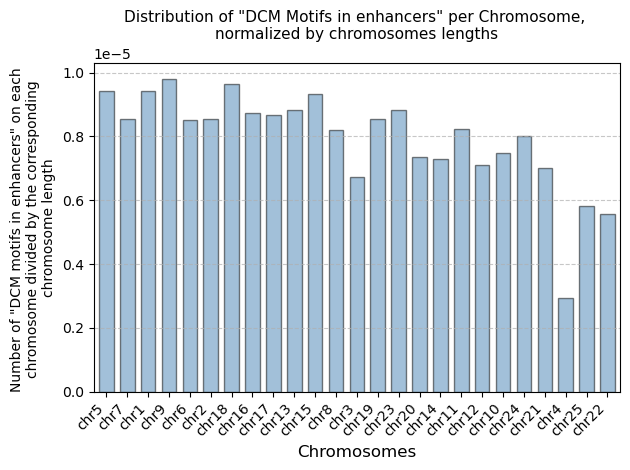

In [41]:
plt.figure(figsize=(40,20))

# Distribution of DCM motifs in Ensembl annotation, normalized
tmp_merged.plot.bar(x='Chromosome',y='count_normalized', color='steelblue', edgecolor='black', width=0.7, alpha=0.5,legend=False)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of "DCM motifs in enhancers" on each \nchromosome divided by the corresponding \nchromosome length', fontsize=10)
plt.title('Distribution of "DCM Motifs in enhancers" per Chromosome, \nnormalized by chromosomes lengths', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*What is the distribution of motifs per enhancer? namely, how many motifs per enhancer?*

In [42]:
motifs_in_enhancers_count = motifs_in_enhancers.groupby('enhancer_ID')['second_idx'].nunique().reset_index(name='motifs_count')
motifs_in_enhancers_count['normalized_count']=motifs_in_enhancers_count['motifs_count']/motifs_in_enhancers['Length']
motifs_in_enhancers_count.head(3)

,enhancer_ID,motifs_count,normalized_count
0,chr10:1003221-1003735,2,0.003752
1,chr10:10168796-10169417,2,0.002853
2,chr10:10245087-10245651,8,0.031746


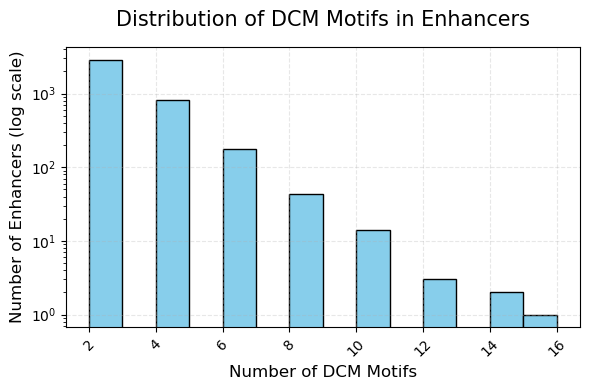

In [43]:
plt.figure(figsize=(6, 4))

x = motifs_in_enhancers_count['motifs_count']

min_val = int(np.floor(min(x)))
max_val = int(np.ceil(max(x)))

n_bins = max_val - min_val  # One bin per integer value
plt.hist(x, bins=n_bins, color='skyblue', edgecolor='black', alpha=1, rwidth=1)

plt.xlabel('Number of DCM Motifs', fontsize=12)
plt.ylabel('Number of Enhancers (log scale)', fontsize=12)
plt.title('Distribution of DCM Motifs in Enhancers', fontsize=15, pad=15)

min_val = int(np.floor(min(x)))
max_val = int(np.ceil(max(x)))
even_ticks = np.arange(min_val + min_val%2, max_val+1, 2.0)
plt.xticks(even_ticks, rotation=45)
plt.yscale('log')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### **Motifs enrichment analysis**
- total length of enhancers versus rest of the genome
- proportion of motifs in at least one enhancer versus not in any enhancer

*Proportion of genome overlapped by enhancers*

Text(0.5, 1.0, 'Proportion of the genome overlapped by weak enhancers, \nconsidering the genome annotation of Ensembl (GRCz11.113) \nand the enhancers annotation provided by Danio Code for longPec stage')

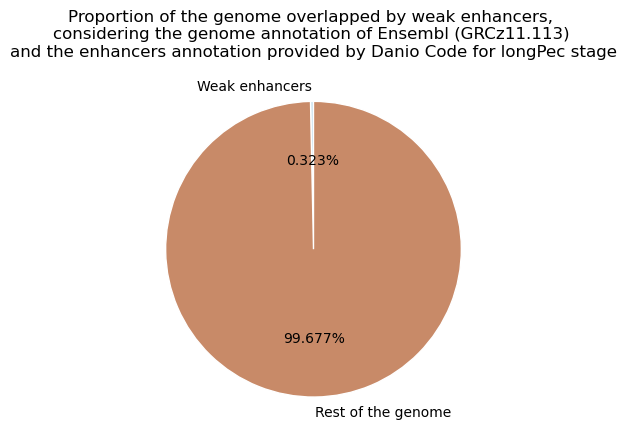

In [49]:
# Total length of enhancers in ZF genome
enhancers_length = enhancers_ranges.merge(False).length

# Length of ZF genome
genome_length=1373471384

# Length of non-enhancers in ZF genome
not_enhancers_length = genome_length - enhancers_length

# Percentages
percent_enhancers=round(get_percentage(enhancers_length,genome_length),10)
percent_not_enhancers=round(get_percentage(not_enhancers_length,genome_length),10)

fig, ax = plt.subplots()
percentage=[percent_enhancers,percent_not_enhancers]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)),alpha=0.7)
ax.pie(percentage, labels=["Weak enhancers", "Rest of the genome"], autopct='%1.3f%%', colors=colors,startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title("Proportion of the genome overlapped by weak enhancers, \nconsidering the genome annotation of Ensembl (GRCz11.113) \nand the enhancers annotation provided by Danio Code for longPec stage")

*Proportion of motifs in enhancers*

Percentage of motifs that are found in at least one enhancer: 0.37%


Text(0.5, 1.0, 'Proportion DCM motifs found in weak enhancers, \nconsidering the genome annotation of Ensembl (GRCz11.113) \nand the enhancers annotation provided by Danio Code for longPec stage')

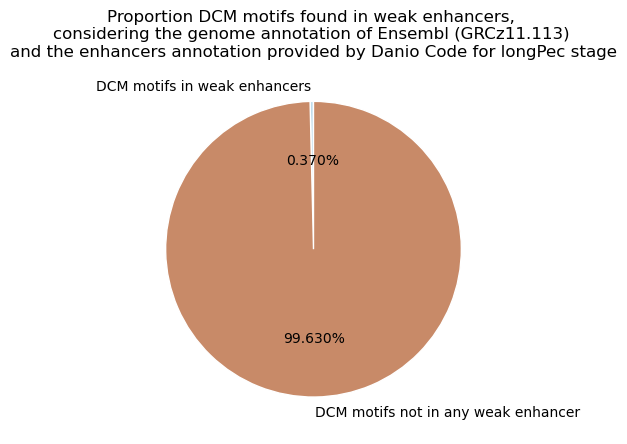

In [51]:
total_motifs = len(motifs)
length_motifs_in_enhancers = motifs_in_enhancers['second_idx'].nunique()

percent_motifs_in_enhancer = round(get_percentage(length_motifs_in_enhancers,total_motifs),2)
percent_motifs_not_in_enhancer = round(get_percentage(total_motifs - length_motifs_in_enhancers,total_motifs),2)

print(f"Percentage of motifs that are found in at least one enhancer: {percent_motifs_in_enhancer}%")

fig, ax = plt.subplots()
percentage=[percent_motifs_in_enhancer,percent_motifs_not_in_enhancer]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)),alpha=0.7)
ax.pie(percentage, labels=["DCM motifs in weak enhancers", "DCM motifs not in any weak enhancer"], autopct='%1.3f%%', colors=colors,startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title("Proportion DCM motifs found in weak enhancers, \nconsidering the genome annotation of Ensembl (GRCz11.113) \nand the enhancers annotation provided by Danio Code for longPec stage")